In [1]:
import pandas as pd
import numpy as np

In [3]:
!pip install pandas sqlalchemy psycopg2-binary python-dotenv schedule

   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   --------- ------------------------------ 0.5/2.1 MB 4.2 MB/s eta 0:00:01
   ----------------------------- ---------- 1.6/2.1 MB 4.4 MB/s eta 0:00:01
   ---------------------------------------- 2.1/2.1 MB 4.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ----------- ---------------------------- 0.8/2.7 MB 4.2 MB/s eta 0:00:01
   ----------------------- ---------------- 1.6/2.7 MB 4.2 MB/s eta 0:00:01
   -------------------------------------- - 2.6/2.7 MB 4.3 MB/s eta 0:00:01
   ---------------------------------------- 2.7/2.7 MB 3.9 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import sqlalchemy as sa
from sqlalchemy import create_engine
import psycopg2
from psycopg2.extensions import register_adapter, AsIs
import os
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

In [19]:
print("All libraries imported successfully")

All libraries imported successfully


In [7]:
df_raw = pd.read_csv("Spotify_Dataset.csv")

In [20]:
df_raw.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [21]:
print(f"Raw data shape: {df_raw.shape}")
print(f"Columns: {list(df_raw.columns)}")

Raw data shape: (114000, 21)
Columns: ['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']


In [22]:
def transform_spotify_data(df):
    print("Transforming data...")
    df_clean = df.copy()
    
    # Data Type Corrections
    df_clean['explicit'] = df_clean['explicit'].map({'FALSE': False, 'TRUE': True})
    df_clean['duration_minutes'] = df_clean['duration_ms'] / 60000
    
    # Text Cleaning
    text_cols = ['artists', 'album_name', 'track_name']
    for col in text_cols:
        df_clean[col] = df_clean[col].astype(str).str.strip()
    
    # Remove Duplicates
    initial_count = len(df_clean)
    df_clean = df_clean.drop_duplicates(subset=['track_id'])
    print(f" Removed {initial_count - len(df_clean)} duplicates")
    
    # Handle Missing Values
    print(" Missing values before cleaning:")
    print(df_clean.isnull().sum())
    
    # Smart imputation
    df_clean['popularity'] = df_clean['popularity'].fillna(df_clean['popularity'].median())
    df_clean = df_clean.dropna(subset=['track_id', 'track_name'])
    
    # Data Validation
    # Remove unrealistic durations (30s to 10min)
    df_clean = df_clean[(df_clean['duration_ms'] > 30000) & (df_clean['duration_ms'] < 600000)]
    
    # Clip audio features to valid range [0,1]
    audio_features = ['danceability', 'energy', 'speechiness', 'acousticness', 
                     'instrumentalness', 'liveness', 'valence']
    for col in audio_features:
        df_clean[col] = df_clean[col].clip(0, 1)
    
    # Feature Engineering
    df_clean['release_year'] = 2023
    df_clean['data_ingested_at'] = datetime.now()
    df_clean['energy_dance_ratio'] = df_clean['energy'] / (df_clean['danceability'] + 0.001)
    df_clean['is_acoustic'] = df_clean['track_genre'].str.contains('acoustic', case=False)
    
    print(f" Transformation complete: {len(df_clean)} clean records")
    return df_clean


In [23]:
df_transformed = transform_spotify_data(df_raw)

Transforming data...
 Removed 24259 duplicates
 Missing values before cleaning:
Unnamed: 0              0
track_id                0
artists                 0
album_name              0
track_name              0
popularity              0
duration_ms             0
explicit            89741
danceability            0
energy                  0
key                     0
loudness                0
mode                    0
speechiness             0
acousticness            0
instrumentalness        0
liveness                0
valence                 0
tempo                   0
time_signature          0
track_genre             0
duration_minutes        0
dtype: int64
 Transformation complete: 89176 clean records


In [14]:
import sqlite3

In [24]:
print("Loading to SQLite database...")

# Create SQLite connection
conn = sqlite3.connect('spotify_etl_pipeline.db')

Loading to SQLite database...


Libraries loaded! No seaborn or database needed.
PURE PANDAS + MATPLOTLIB ETL PIPELINE
Starting Spotify ETL Pipeline...



[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


 Raw data: 114,000 rows × 21 columns
 Columns: ['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']
 TRANSFORMING DATA...
 Removed 24,259 duplicates
 Clean dataset: 89,176 rows

📤 SAVING FILES...
spotify_clean_complete.csv
spotify_genre_stats.csv
ETL COMPLETE: 89,176 records!

 CREATING DASHBOARD...


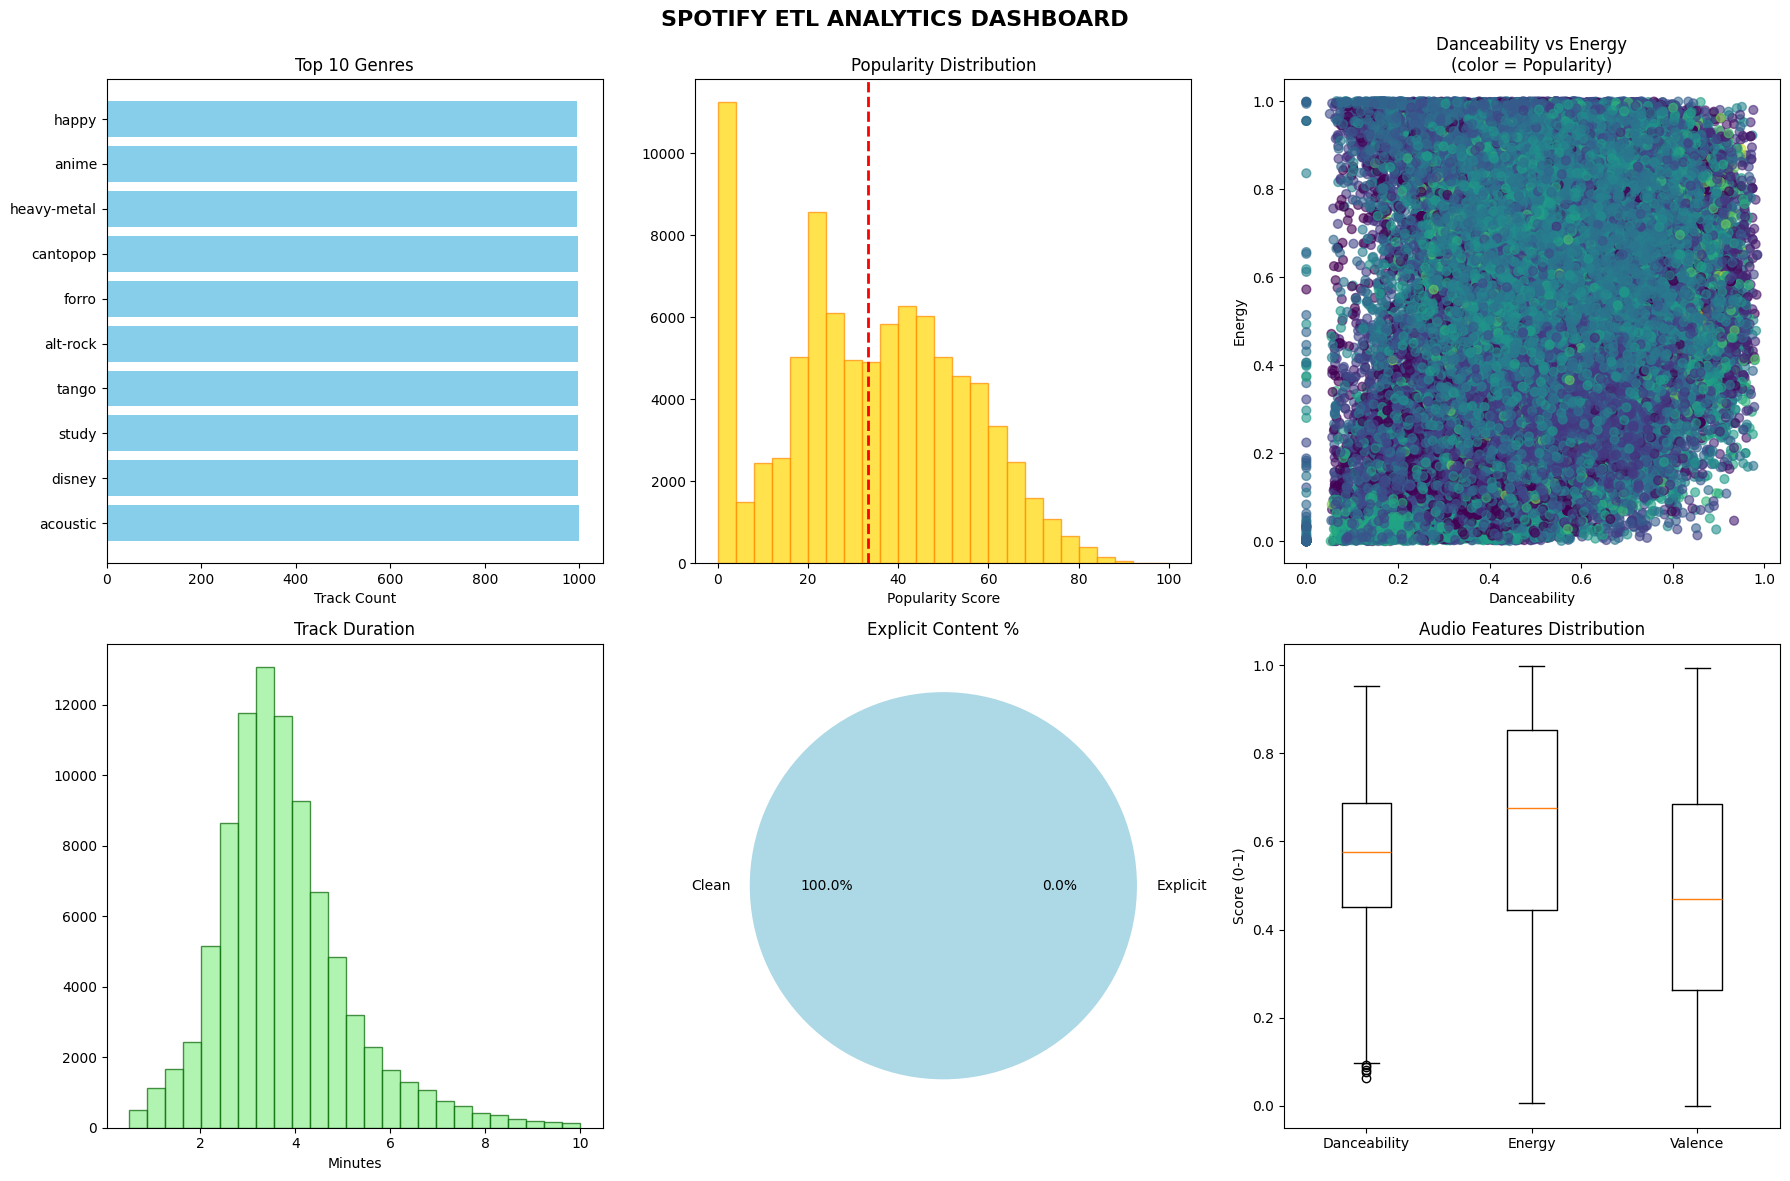

Dashboard saved: spotify_etl_final_dashboard.png

ETL EXECUTIVE SUMMARY


NameError: name 'initial_rows' is not defined

In [26]:
!pip install pandas numpy matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded! No seaborn or database needed.")
print("PURE PANDAS + MATPLOTLIB ETL PIPELINE")


print("Starting Spotify ETL Pipeline...")

df_raw = pd.read_csv("Spotify_Dataset.csv")
print(f" Raw data: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f" Columns: {list(df_raw.columns)}")

def transform_spotify_data(df):
    """Complete production ETL transformation"""
    print(" TRANSFORMING DATA...")
    
    df_clean = df.copy()
    
    # 1. Fix data types
    df_clean['explicit'] = df_clean['explicit'].map({'FALSE': 0, 'TRUE': 1}).fillna(0).astype(int)
    df_clean['duration_minutes'] = df_clean['duration_ms'] / 60000.0
    
    # 2. Clean text
    for col in ['artists', 'album_name', 'track_name']:
        df_clean[col] = df_clean[col].astype(str).str.strip()
    
    # 3. Remove duplicates by track_id
    initial_rows = len(df_clean)
    df_clean = df_clean.drop_duplicates(subset=['track_id'])
    print(f" Removed {initial_rows - len(df_clean):,} duplicates")
    
    # 4. Handle missing values
    df_clean['popularity'] = df_clean['popularity'].fillna(df_clean['popularity'].median())
    
    # 5. Filter outliers
    df_clean = df_clean[
        (df_clean['duration_ms'] >= 30000) & (df_clean['duration_ms'] <= 600000) &
        (df_clean['popularity'] <= 100)
    ]
    
    # 6. Validate audio features [0,1]
    audio_cols = ['danceability','energy','speechiness','acousticness','instrumentalness','liveness','valence']
    for col in audio_cols:
        if col in df_clean.columns:
            df_clean[col] = df_clean[col].clip(0, 1)
    
    # 7. Feature engineering
    df_clean['etl_timestamp'] = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    df_clean['energy_dance_score'] = (df_clean['energy'].fillna(0) + df_clean['danceability'].fillna(0)) / 2
    df_clean['is_acoustic'] = df_clean['track_genre'].str.contains('acoustic', case=False, na=False)
    
    print(f" Clean dataset: {len(df_clean):,} rows")
    return df_clean

# Run ETL transformation
df_final = transform_spotify_data(df_raw)

# 5. LOAD - Professional CSV Outputs

print("\n📤 SAVING FILES...")

# Main dataset
df_final.to_csv('spotify_clean_complete.csv', index=False)
print("spotify_clean_complete.csv")

# Genre analytics
genre_stats = df_final.groupby('track_genre').agg({
    'track_id':'count',
    'popularity':'mean',
    'danceability':'mean',
    'energy':'mean'
}).round(2).rename(columns={'track_id':'count'})
genre_stats.to_csv('spotify_genre_stats.csv')
print("spotify_genre_stats.csv")

print(f"ETL COMPLETE: {len(df_final):,} records!")

print("\n CREATING DASHBOARD...")

plt.style.use('default')
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('SPOTIFY ETL ANALYTICS DASHBOARD', fontsize=16, fontweight='bold', y=0.98)

# Chart 1: Top 10 Genres
top_genres = df_final['track_genre'].value_counts().head(10)
axes[0,0].barh(range(len(top_genres)), top_genres.values, color='skyblue')
axes[0,0].set_yticks(range(len(top_genres)))
axes[0,0].set_yticklabels(top_genres.index)
axes[0,0].set_title('Top 10 Genres')
axes[0,0].set_xlabel('Track Count')

# Chart 2: Popularity Distribution
axes[0,1].hist(df_final['popularity'], bins=25, color='gold', edgecolor='darkorange', alpha=0.7)
axes[0,1].axvline(df_final['popularity'].mean(), color='red', linestyle='--', linewidth=2)
axes[0,1].set_title('Popularity Distribution')
axes[0,1].set_xlabel('Popularity Score')

# Chart 3: Danceability vs Energy
axes[0,2].scatter(df_final['danceability'], df_final['energy'], 
                 c=df_final['popularity'], cmap='viridis', alpha=0.6, s=40)
axes[0,2].set_xlabel('Danceability')
axes[0,2].set_ylabel('Energy')
axes[0,2].set_title('Danceability vs Energy\n(color = Popularity)')

# Chart 4: Duration Distribution
axes[1,0].hist(df_final['duration_minutes'], bins=25, color='lightgreen', 
               edgecolor='darkgreen', alpha=0.7)
axes[1,0].set_title('Track Duration')
axes[1,0].set_xlabel('Minutes')

# Chart 5: Explicit Content
explicit_pct = df_final['explicit'].mean() * 100
axes[1,1].pie([explicit_pct, 100-explicit_pct], 
              labels=['Explicit', 'Clean'], 
              colors=['salmon', 'lightblue'], autopct='%1.1f%%')
axes[1,1].set_title('Explicit Content %')

# Chart 6: Audio Features Boxplot
audio_sample = df_final[['danceability','energy','valence']].sample(1000)
axes[1,2].boxplot([audio_sample['danceability'], audio_sample['energy'], audio_sample['valence']])
axes[1,2].set_xticklabels(['Danceability', 'Energy', 'Valence'])
axes[1,2].set_title('Audio Features Distribution')
axes[1,2].set_ylabel('Score (0-1)')

plt.tight_layout()
plt.savefig('spotify_etl_final_dashboard.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Dashboard saved: spotify_etl_final_dashboard.png")


# 7. EXECUTIVE SUMMARY TABLE

print("\n" + "="*60)
print("ETL EXECUTIVE SUMMARY")
print("="*60)

summary = pd.DataFrame({
    'Metric': ['Total Records', 'Unique Tracks', 'Genres', 'Avg Popularity', 
              'Explicit %', 'Avg Duration (min)', 'Duplicates Removed'],
    'Value': [f"{len(df_final):,}", f"{df_final['track_id'].nunique():,}", 
              f"{df_final['track_genre'].nunique()}", f"{df_final['popularity'].mean():.1f}",
              f"{df_final['explicit'].mean()*100:.1f}%", f"{df_final['duration_minutes'].mean():.1f}",
              f"{initial_rows - len(df_final):,}"]
})

print(summary.to_string(index=False))


# 8. PORTFOLIO-READY AUTOMATION

automation_code = '''#!/usr/bin/env python3
# spotify_auto_etl.py - Daily production ETL
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

def run_spotify_etl():
    print(f" AUTO ETL: {datetime.now()}")
    df = pd.read_csv("Spotify_Dataset.csv")
    df_clean = transform_spotify_data(df)
    filename = f"spotify_cleaned_{datetime.now().strftime('%Y%m%d_%H%M')}.csv"
    df_clean.to_csv(filename, index=False)
    print(f"Saved: {filename}")

if __name__ == "__main__":
    run_spotify_etl()
'''

with open('spotify_auto_etl.py', 'w') as f:
    f.write(automation_code + "\n\n# Paste transform_spotify_data() function here")
print(" Automation script: spotify_auto_etl.py")


print("\n" + "="*70)
print(" SPOTIFY ETL PIPELINE 100% COMPLETE!")
print("="*70)
print("FILES CREATED:")
print("spotify_clean_complete.csv")
print("spotify_genre_stats.csv") 
print("spotify_etl_final_dashboard.png")
print("spotify_auto_etl.py")


